In [1]:
# !hpc-ticket
# !hpc-mount wissdaten

In [2]:
from src.dataloading.epidataorchestration import EpiConfig, EpiDataOrchestrator
from src.dataloading import BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ConstantModel, ClimaScaleModel

epiconfig= EpiConfig(
        disease                 = 'influenza',

        split_berlin            = False,

        min_date                = '2011-01-01',
        max_date                = '2024-06-01',
        split_trainval          = '2018-06-01',
        split_valtest           = '2019-06-01',

        horizon_leadtime        = 3,

        sequence_length         = 12,

        feature_popsize         = True,      
        feature_popdens         = True,
        feature_popage          = True,
        feature_gisd            = False,        
        feature_kreise_classes  = False, 
        feature_borders         = False,
        feature_vax             = False,
        feature_climateology    = False,
        time_index_w            = False,
        
        log_transform       = ['incidence']
        )    

data_orch= EpiDataOrchestrator(epiconfig).build()

In [3]:
baseline_data           = BaseLineDataLoaderManager(data_orch)
constant_predictor      = ConstantModel(baseline_data)
persistence_predictor   = PersistenceModel(baseline_data)
climateology            = ClimateologyModel(baseline_data)
climascale              = ClimaScaleModel(baseline_data)

node_sample = 26

constant_predictor.set_model_hparams(0)
constant_predictor.train()
constant_predictor.forecast('test')

persistence_predictor.train()
persistence_predictor.forecast('test')

climateology.train()
climateology.forecast('test')

climascale.train()
climascale.forecast('test')

baselines = [constant_predictor, persistence_predictor, climateology, climascale]

In [4]:
from src.dataloading import BaseLineDataLoaderManager, DeepDataLoaderManager,GraphDataLoaderManager

n_epochs        = 500
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.2, 'patience': 5},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

baselinedataloader  = BaseLineDataLoaderManager(data_orch)
deepdataloader      = DeepDataLoaderManager(data_orch).build()
graphloader1        = GraphDataLoaderManager(data_orch).retrieve_static_graph('test2').build()


==                     lstm                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 20, 12), y=(400, 1))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.9522   |   1.7801   |    v     |           |
|  002  |   0.7907   |   1.3078   |    v     |           |
|  003  |   0.6486   |   0.9475   |    v     |           |
|  004  |   0.5717   |   0.7879   |    v     |           |
|  005  |   0.5352   |   0.7220   |    v     |           |
|  006  |   0.5179   |   0.6846   |    v     |           |
|  007  |   0.5033   |   0.6616   |    v     |           |
|  008  |   0.4922   |   0.6448   |    v     |           |
|  009  |   0.4831   |   0.6348   |    v     |           |
|  010  |   0.4784   |   0.6246   |    v     |           |
|  011  |   0.4737   |   0.6200   |    v     |           |
|  012  |   0.4699   |   0.6132   |    v     |           |
|  013  |   0.4657   |

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.5699
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [00:00<00:00, 655.07it/s]


Test loss: 0.7575
forecasted ✓


<Fig(n_axes = 1, legend, ticks, labels)>

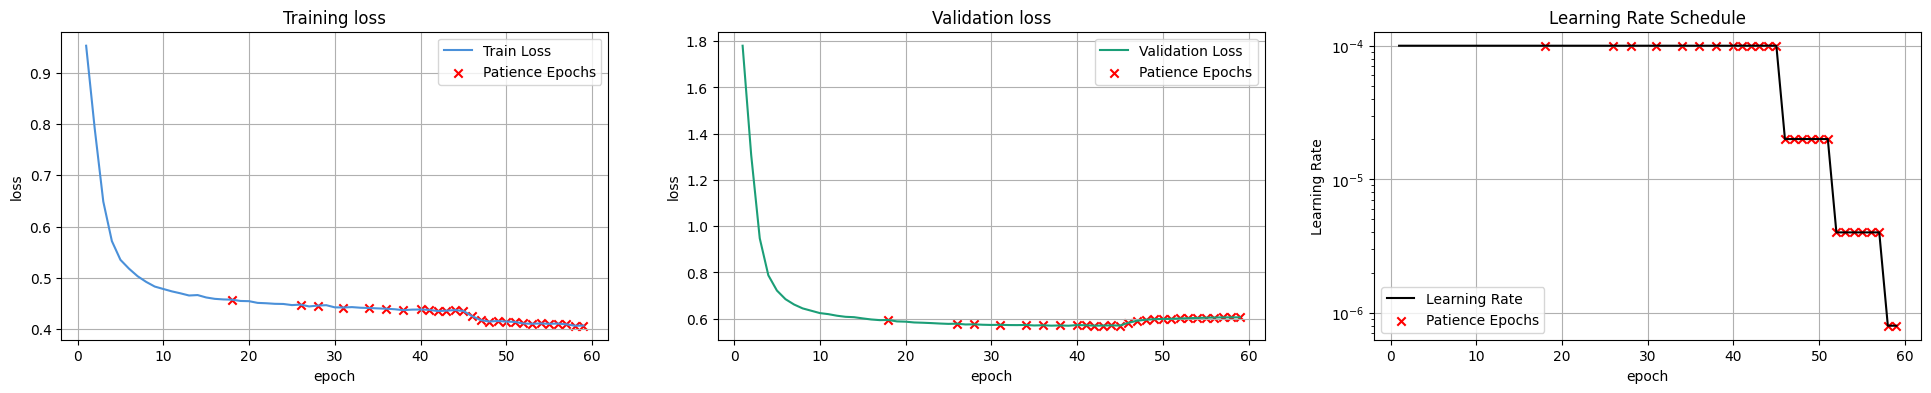

In [5]:
from src.models import LSTMModel, GCNLSTMModel

lstm = LSTMModel(deepdataloader, name = 'lstm', verbose = 2)
lstm.set_model_hparams(hidden_size=128, dropout = 0.3)
lstm.set_global_hparams(**global_hparams)
lstm.train()
lstm.forecast('test')
lstm.show_forecasts(26)



==            geographical-neighbors            ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 20, 12), y=(400, 1), edge_index=(2, 2088), edge_weight=(2088,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.9236   |   1.1899   |    v     |           |
|  002  |   0.6745   |   0.8077   |    v     |           |
|  003  |   0.6063   |   0.7303   |    v     |           |
|  004  |   0.5808   |   0.6428   |    v     |           |
|  005  |   0.5594   |   0.7244   |          |   1/20    |
|  006  |   0.5490   |   0.6688   |          |   2/20    |
|  007  |   0.5312   |   0.6876   |          |   3/20    |
|  008  |   0.5224   |   0.7060   |          |   4/20    |
|  009  |   0.5079   |   0.6069   |    v     |           |
|  010  |   0.5073   |   0.7292   |          |   1/20    |
|  011  |   0.4984   |   0.6402   |          |   2/20    |
|  012  |   0.4897   |   0.6089   |  

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4191
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [00:00<00:00, 387.21it/s]


Test loss: 0.6323
forecasted ✓


<Fig(n_axes = 1, legend, ticks, labels)>

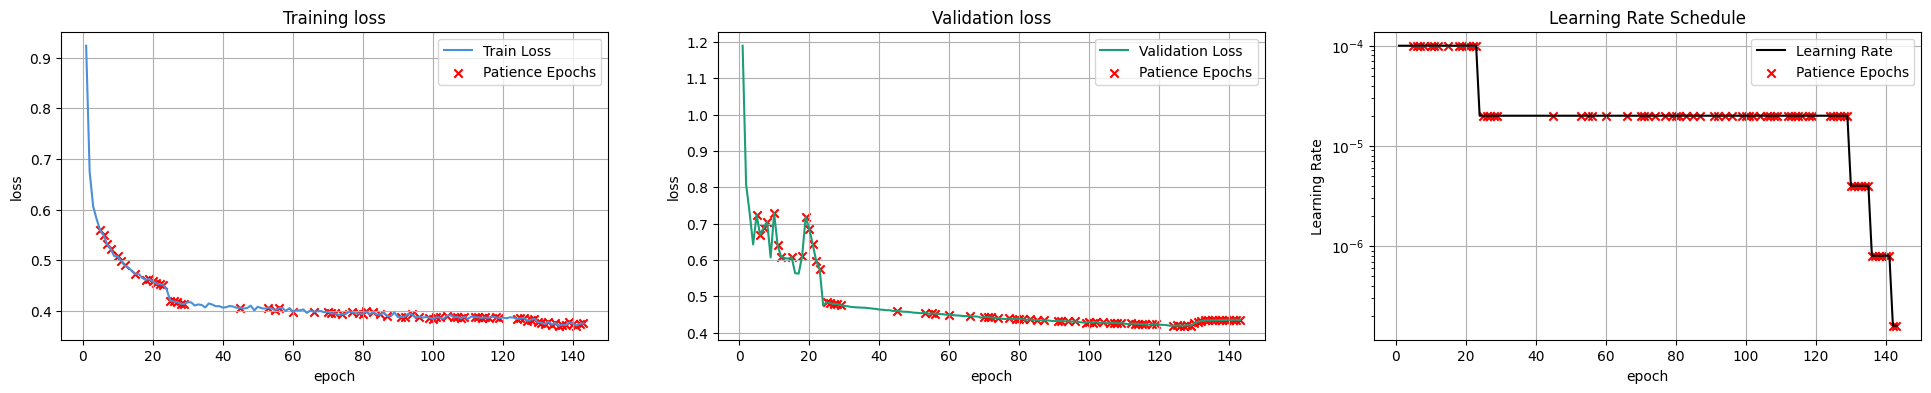

In [6]:
from src.models import GCN2Model
graphloader1        = GraphDataLoaderManager(data_orch).retrieve_static_graph('test1').build()
gcn2_geoneighbors = GCN2Model(graphloader1, name = 'geographical-neighbors', verbose = 2)
gcn2_geoneighbors.set_model_hparams(dropout = 0.3, self_loops=True)
gcn2_geoneighbors.set_global_hparams(**global_hparams)
gcn2_geoneighbors.train()
gcn2_geoneighbors.forecast('test')
gcn2_geoneighbors.show_forecasts(26)

In [7]:
from src.models import GCN2Model
graphloader2        = GraphDataLoaderManager(data_orch).retrieve_static_graph('test3').build()
gcn2_identity = GCN2Model(graphloader2, name = 'identity-graph', verbose = 2)
gcn2_identity.set_model_hparams(dropout = 0.3, self_loops=False)
gcn2_identity.set_global_hparams(**global_hparams)
gcn2_identity.train()
gcn2_identity.forecast('test')
gcn2_identity.show_forecasts(26)


==                identity-graph                ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 20, 12), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.8883   |   0.9974   |    v     |           |
|  002  |   0.6567   |   0.7323   |    v     |           |
|  003  |   0.6087   |   0.6600   |    v     |           |
|  004  |   0.5910   |   0.6465   |    v     |           |


KeyboardInterrupt: 

  0%|                                                                                                                                                                                | 0/2000 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 731.15it/s]


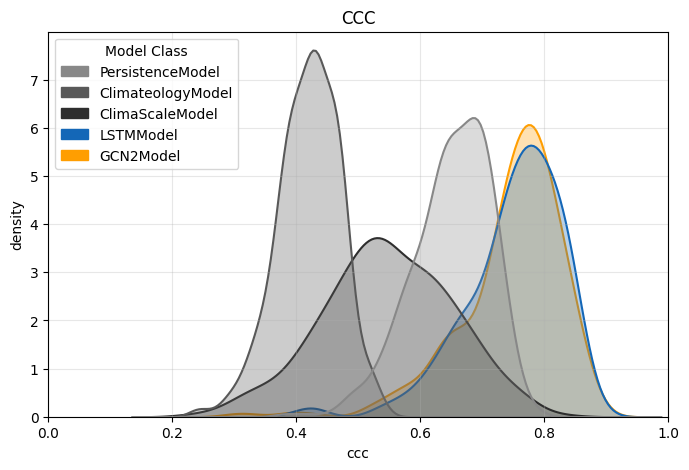

In [ ]:
from src.evaluation import Evaluator

models = baselines[1:] + [lstm,gcn2_identity]

model_evaluation1 = Evaluator(models).add_evaluation()
model_evaluation1.plotter.plot_single_metric('ccc',0,plot_type = 'kde', vmin = 0, vmax=1, log=False).show()

computing metrics nodewise: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 732.42it/s]


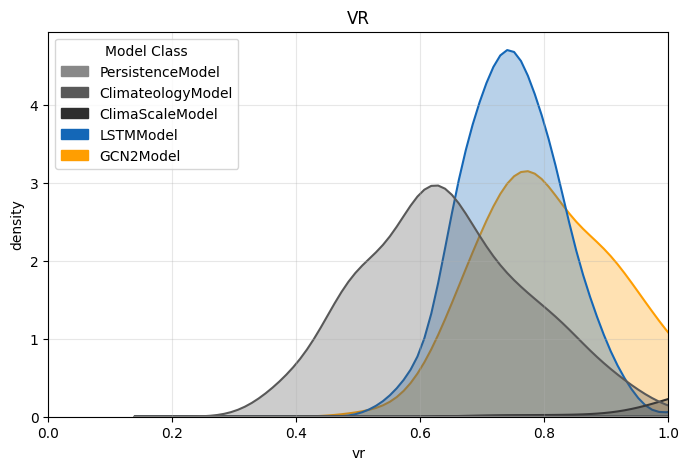

In [ ]:
from src.evaluation import Evaluator

models = baselines[1:] + [lstm,gcn2_geoneighbors]

model_evaluation2 = Evaluator(models).add_evaluation()
model_evaluation2.plotter.plot_single_metric('ccc',0,plot_type = 'kde', vmin = 0, vmax=1, log=False).show()

In [9]:
model_evaluation1.plotter.plot_single_metric('ccc', horizon = 0, plot_type = 'best_map',margin_sd=0.5, best_lowest=False).show()

NameError: name 'model_evaluation1' is not defined

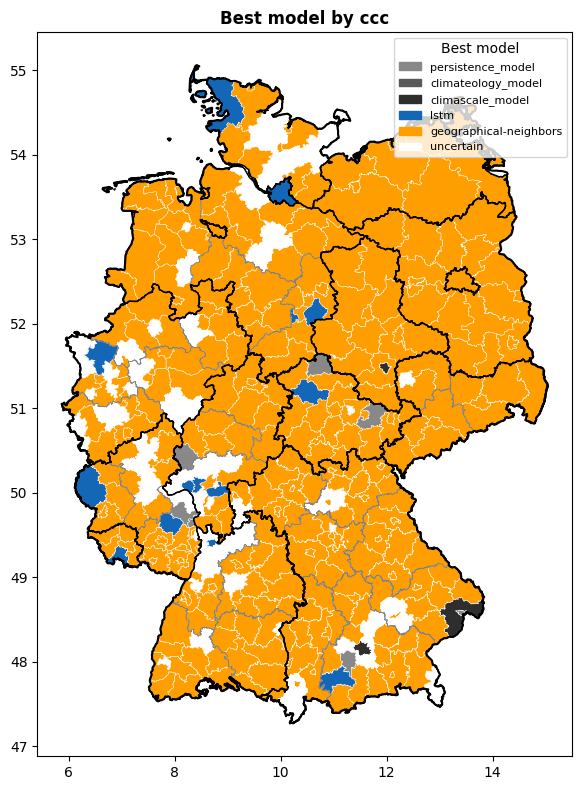

In [10]:
model_evaluation2.plotter.plot_single_metric('ccc', horizon = 0, plot_type = 'best_map',margin_sd=0.5, best_lowest=False).show()

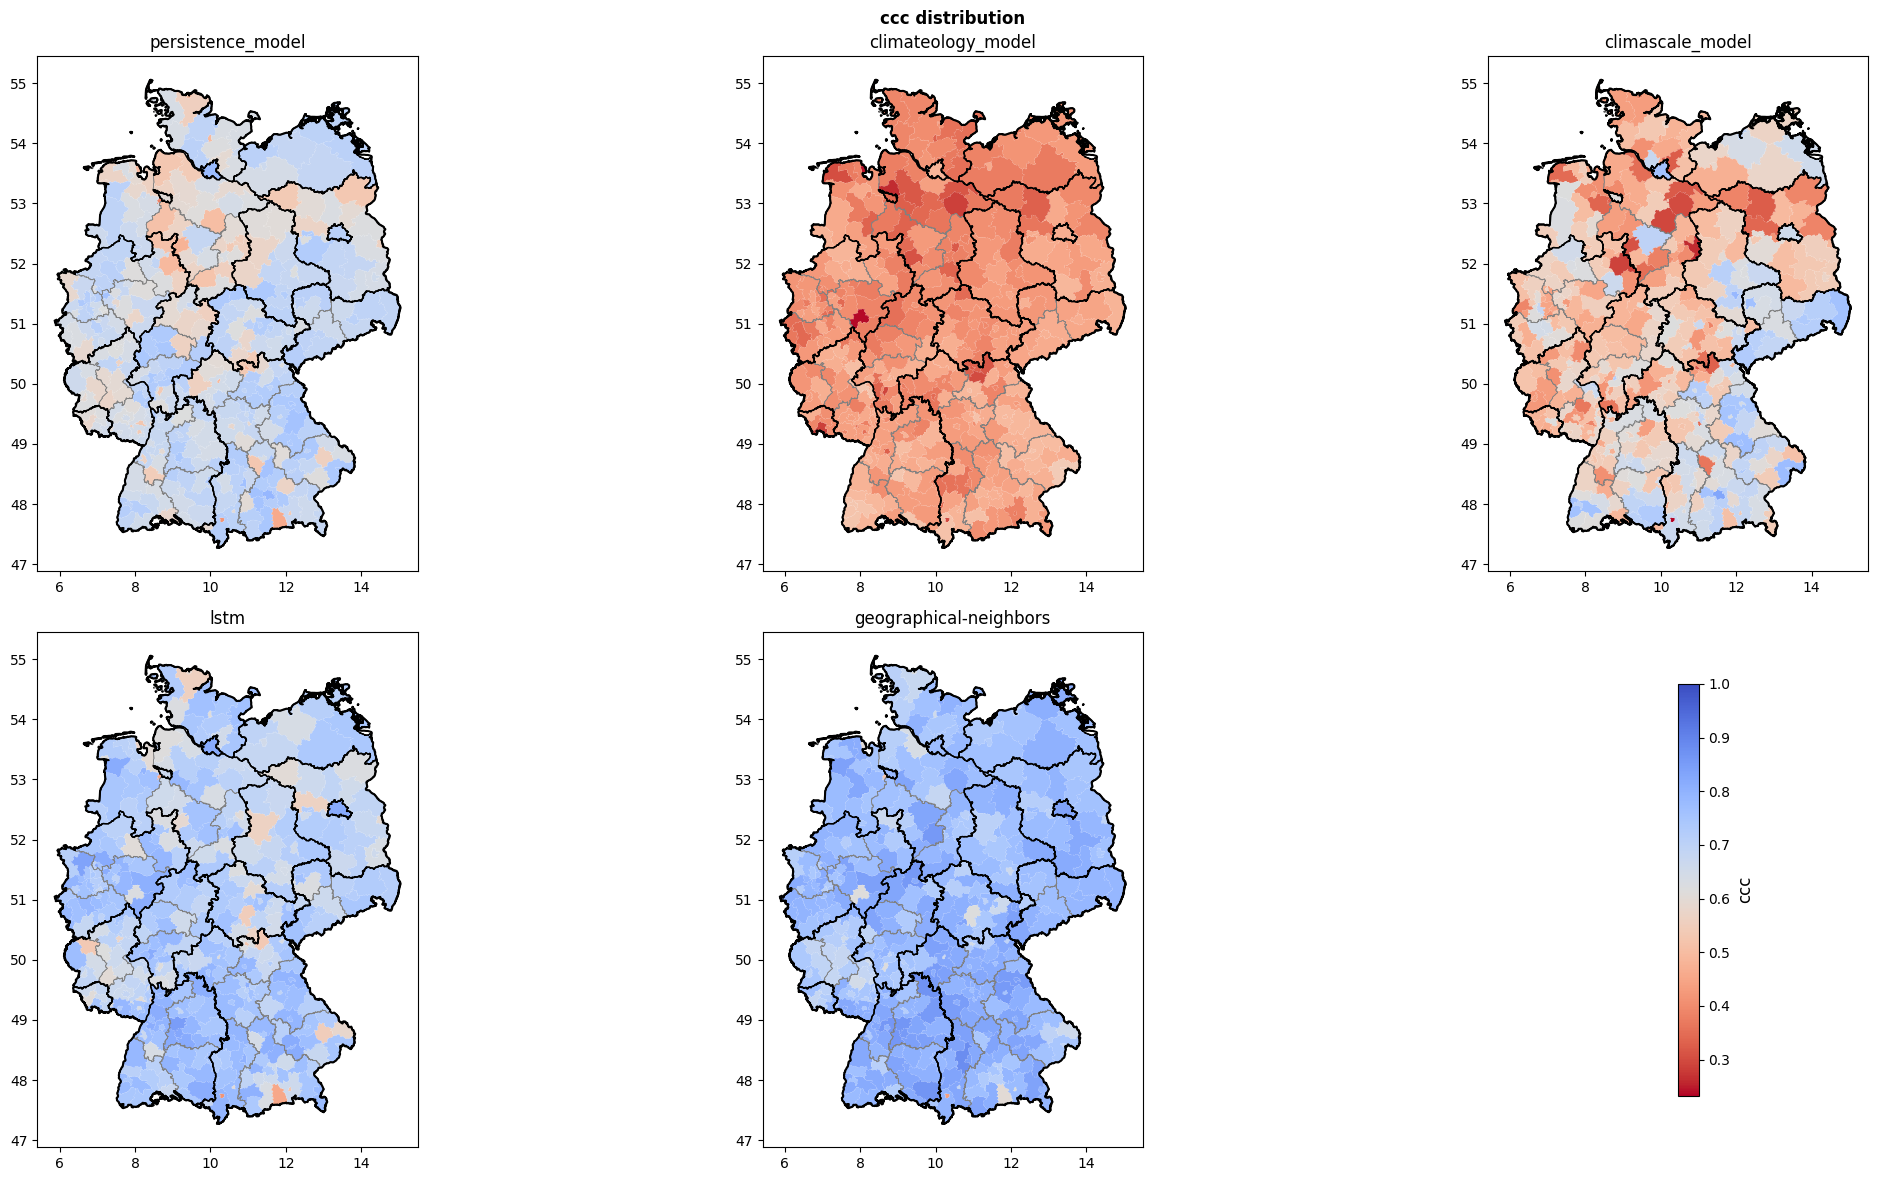

In [11]:
model_evaluation2.plotter.plot_single_metric('ccc', horizon = 0, plot_type = 'map',reverse_scale=True, vmin = 0, vmax = 1)

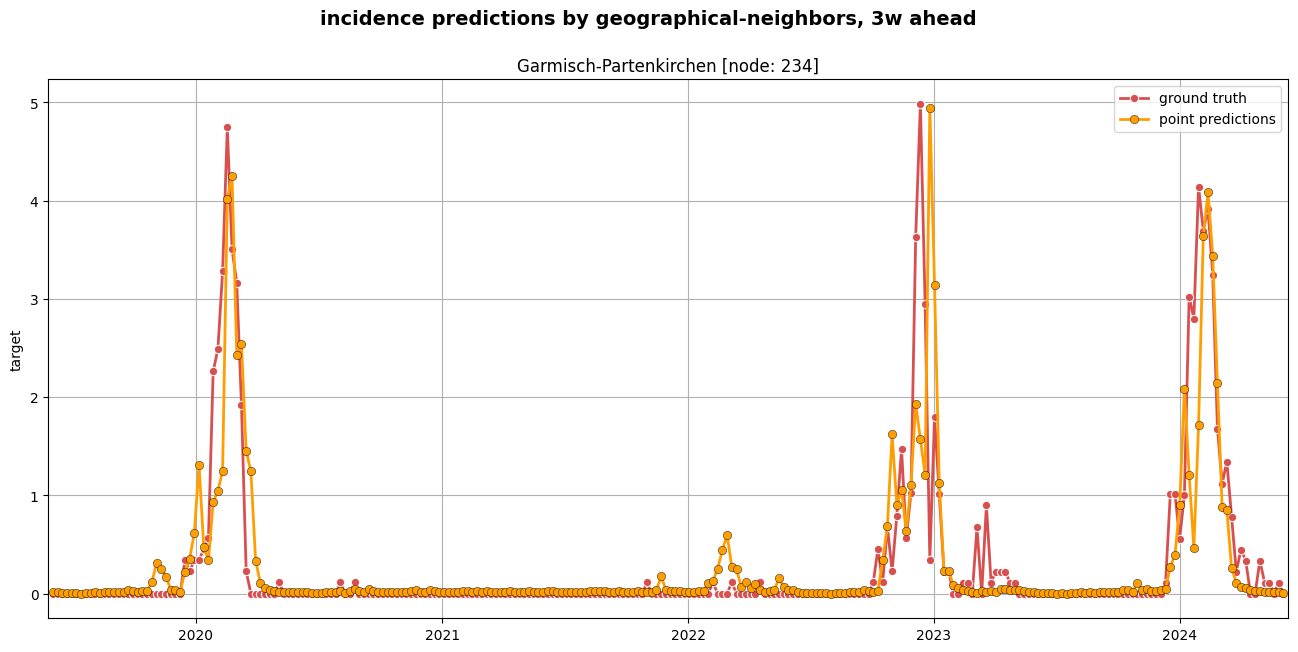

In [12]:
gcn2_geoneighbors.show_forecasts(234).show()

In [ ]:
df = model_evaluation2.data_compilation.get_data(0,'test')['metrics']

metric = 'ccc'

df_wide = df[['nuts_node','model','ccc']]
df_wide = df_wide.pivot_table(index = 'nuts_node', columns = 'model', values = 'ccc').reset_index(drop = False)
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(df_wide['geographical-neighbors'].dropna(), df_wide['lstm'].dropna(), alternative='greater')  # 'less' if lower is better
print(f"U={stat}, p={p}")

U=104088.0, p=8.489567015757072e-14


In [ ]:
from scipy.stats import wilcoxon
import pandas as pd

def compare_models_wilcoxon(df_wide: pd.DataFrame, model1: str, model2: str):

    x = df_wide[model1]
    y = df_wide[model2]

    # remove rows where either model is NaN
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]

    stat, p = wilcoxon(x, y, alternative='greater')

    print(f"Wilcoxon statistic = {stat}")
    print(f"p-value = {p}")

In [ ]:
compare_models_wilcoxon(df_wide, 'geographical-neighbors','lstm')

Wilcoxon statistic = 70058.0
p-value = 1.2070377216359812e-38


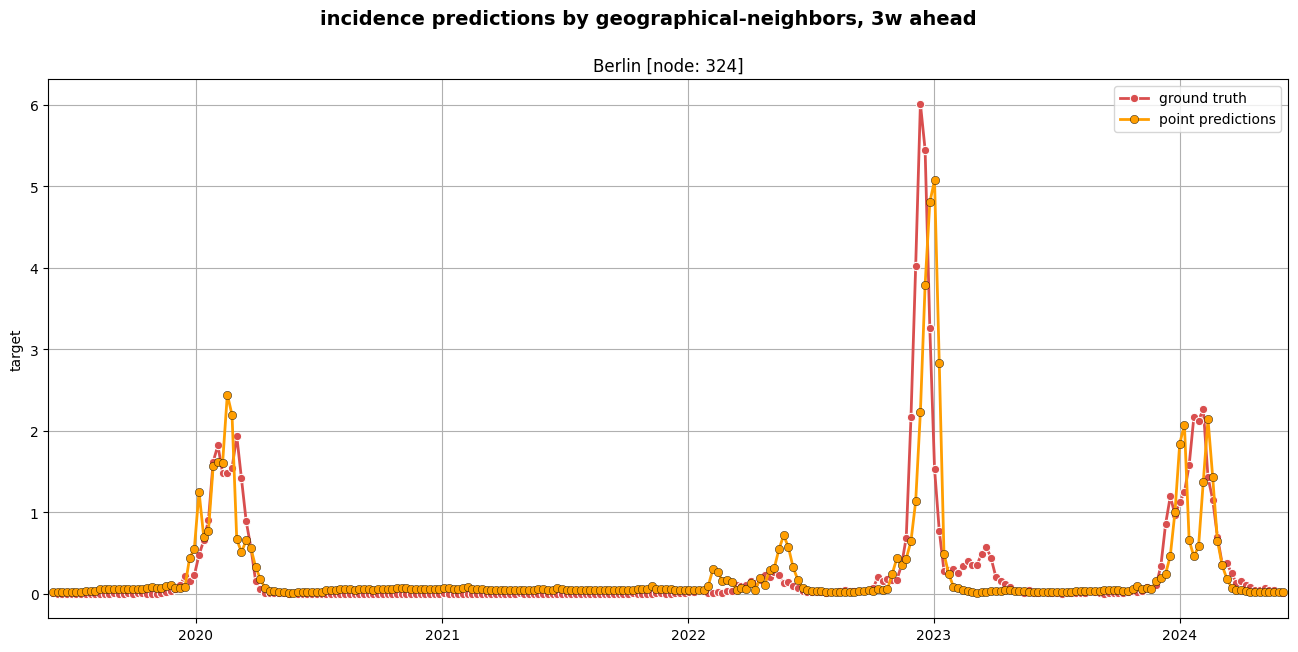

In [15]:
gcn2_geoneighbors.show_forecasts(324).show()

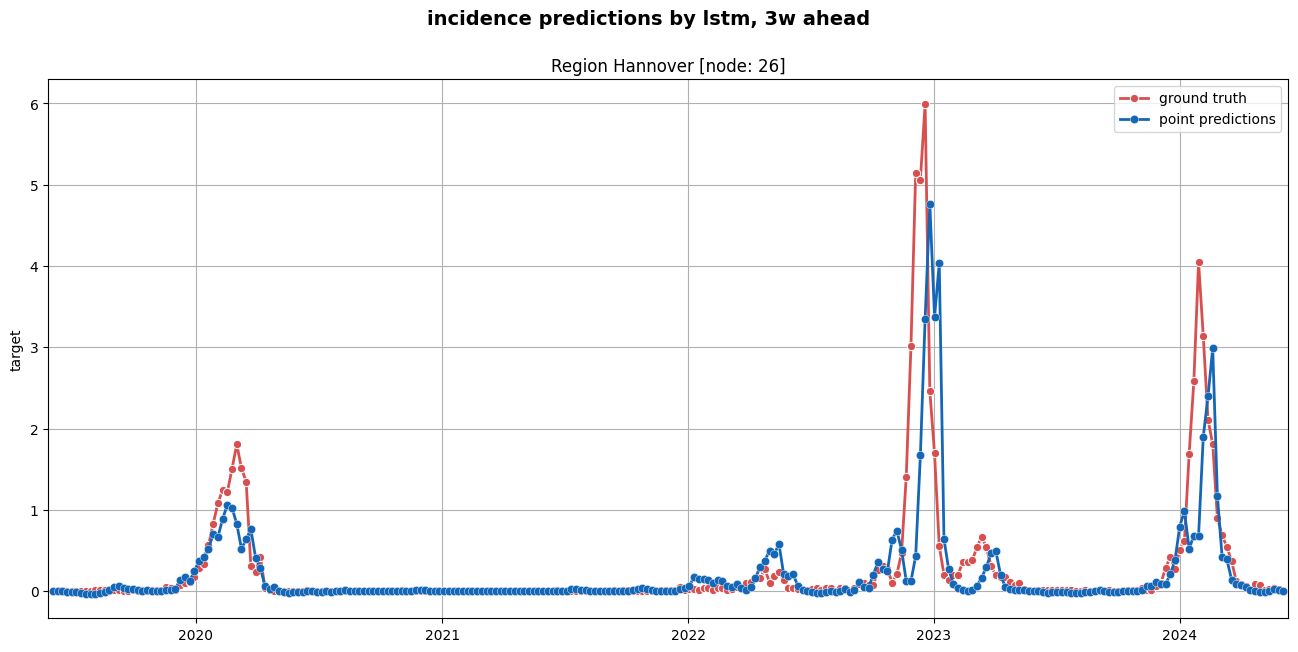

In [14]:
lstm.show_forecasts(26).show()